# Cows2021 Dataset Analysis

**Dataset:** Cows2021 (detection and localisation subset)  
**Notebook:** `notebooks/dataset_analysis/analysis_cows2021.ipynb`  
**Output:** `results/analysis/cows2021_summary.json`

Derives all statistics from `data/raw/cows2021/` only. No pipeline outputs are read.


In [1]:
import sys, json, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

REPO_ROOT = Path("../..")
RAW = REPO_ROOT / "data" / "raw" / "cows2021"
RESULTS_DIR = REPO_ROOT / "results" / "analysis"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SPLITS = ["train", "val", "test"]


def ann_dir(split: str) -> Path:
    return RAW / f"detection_and_localisation-{split}" / "ann"


def img_dir(split: str) -> Path:
    return RAW / f"detection_and_localisation-{split}" / "img"


print("RAW path:", RAW.resolve())
for split in SPLITS:
    n_ann = len(list(ann_dir(split).glob("*.json")))
    n_img = len(list(img_dir(split).glob("*.jpg")))
    print(f"  {split:<6}: {n_ann:>5} annotation files, {n_img:>5} images")

RAW path: /home/sakif/TXST/Thesis/cattle-vision-framework/data/raw/cows2021
  train :  7248 annotation files,  7248 images
  val   :  1023 annotation files,  1023 images
  test  :  2131 annotation files,  2131 images


---

## 1. Dataset Overview

**Origin:** Cows2021 is a top-down overhead-view Holstein-Friesian cattle dataset captured inside a barn. Images were extracted from video footage of a single pen filmed from a fixed ceiling-mounted camera. The dataset was released by the University of Bristol (Gao et al., 2021) and made available via DatasetNinja.

**Paper:** _"Towards Self-Supervised Cattle Identification via Body Pattern Learning"_ (Gao et al., 2021). Original paper includes identity re-identification; this analysis uses the **detection and localisation** subset only.

**License:** CC BY 4.0 (via DatasetNinja).

**Annotation format:** DatasetNinja/Supervisely JSON — one `.jpg.json` file per image at `detection_and_localisation-{split}/ann/{id}.jpg.json`. Each file contains a `size` dict (`height`, `width`) and an `objects` list; each object has `classTitle = 'cattle torso'` and `points.exterior` (two corner coordinates `[x1, y1], [x2, y2]`).

**Single detection class:** `cattle torso` — top-down bounding box around each visible cow body.

**Distinctive visual characteristic:** Holstein-Friesian black-and-white coat pattern, overhead view. This creates a very different appearance from the side-view surveillance footage in CBVD-5 and CVB.

**Role in thesis pipeline (Phase 8):**

- **Detection mAP** — OOD generalization test for RF-DETR trained on CBVD-5 + CVB
- **Short-term tracking IDF1** — evaluate OC-SORT on overhead multi-cow sequences
- **No behavior labels** — this dataset is detection + identity only; behavior classification is out of scope


---

## 2. Data Inventory


In [2]:
split_stats = {}

for split in SPLITS:
    ann_files = sorted(ann_dir(split).glob("*.json"))
    img_files = sorted(img_dir(split).glob("*.jpg"))

    n_boxes = 0
    boxes_per_image = []
    for f in ann_files:
        d = json.loads(f.read_text())
        boxes = [o for o in d["objects"] if o.get("classTitle") == "cattle torso"]
        n_boxes += len(boxes)
        boxes_per_image.append(len(boxes))

    split_stats[split] = {
        "n_images": len(ann_files),
        "n_boxes": n_boxes,
        "boxes_per_image": boxes_per_image,
    }

total_images = sum(s["n_images"] for s in split_stats.values())
total_boxes = sum(s["n_boxes"] for s in split_stats.values())

print(
    f"{'Split':<8} {'Images':>8} {'Boxes':>8} {'Boxes/img mean':>16} {'Boxes/img max':>15}"
)
print("-" * 60)
for split in SPLITS:
    s = split_stats[split]
    bpi = s["boxes_per_image"]
    print(
        f"{split:<8} {s['n_images']:>8,} {s['n_boxes']:>8,} "
        f"{np.mean(bpi):>16.2f} {max(bpi):>15}"
    )
print("-" * 60)
all_bpi = [b for s in split_stats.values() for b in s["boxes_per_image"]]
print(
    f"{'TOTAL':<8} {total_images:>8,} {total_boxes:>8,} "
    f"{np.mean(all_bpi):>16.2f} {max(all_bpi):>15}"
)
print()
print("Image format:      .jpg")
print("Annotation format: DatasetNinja/Supervisely JSON (.jpg.json per image)")
print("Single class:      'cattle torso' (detection bounding box only)")

Split      Images    Boxes   Boxes/img mean   Boxes/img max
------------------------------------------------------------
train       7,248    9,408             1.30               5
val         1,023    1,238             1.21               4
test        2,131    2,532             1.19               4
------------------------------------------------------------
TOTAL      10,402   13,178             1.27               5

Image format:      .jpg
Annotation format: DatasetNinja/Supervisely JSON (.jpg.json per image)
Single class:      'cattle torso' (detection bounding box only)


---

## 3. Sample Image Visualization


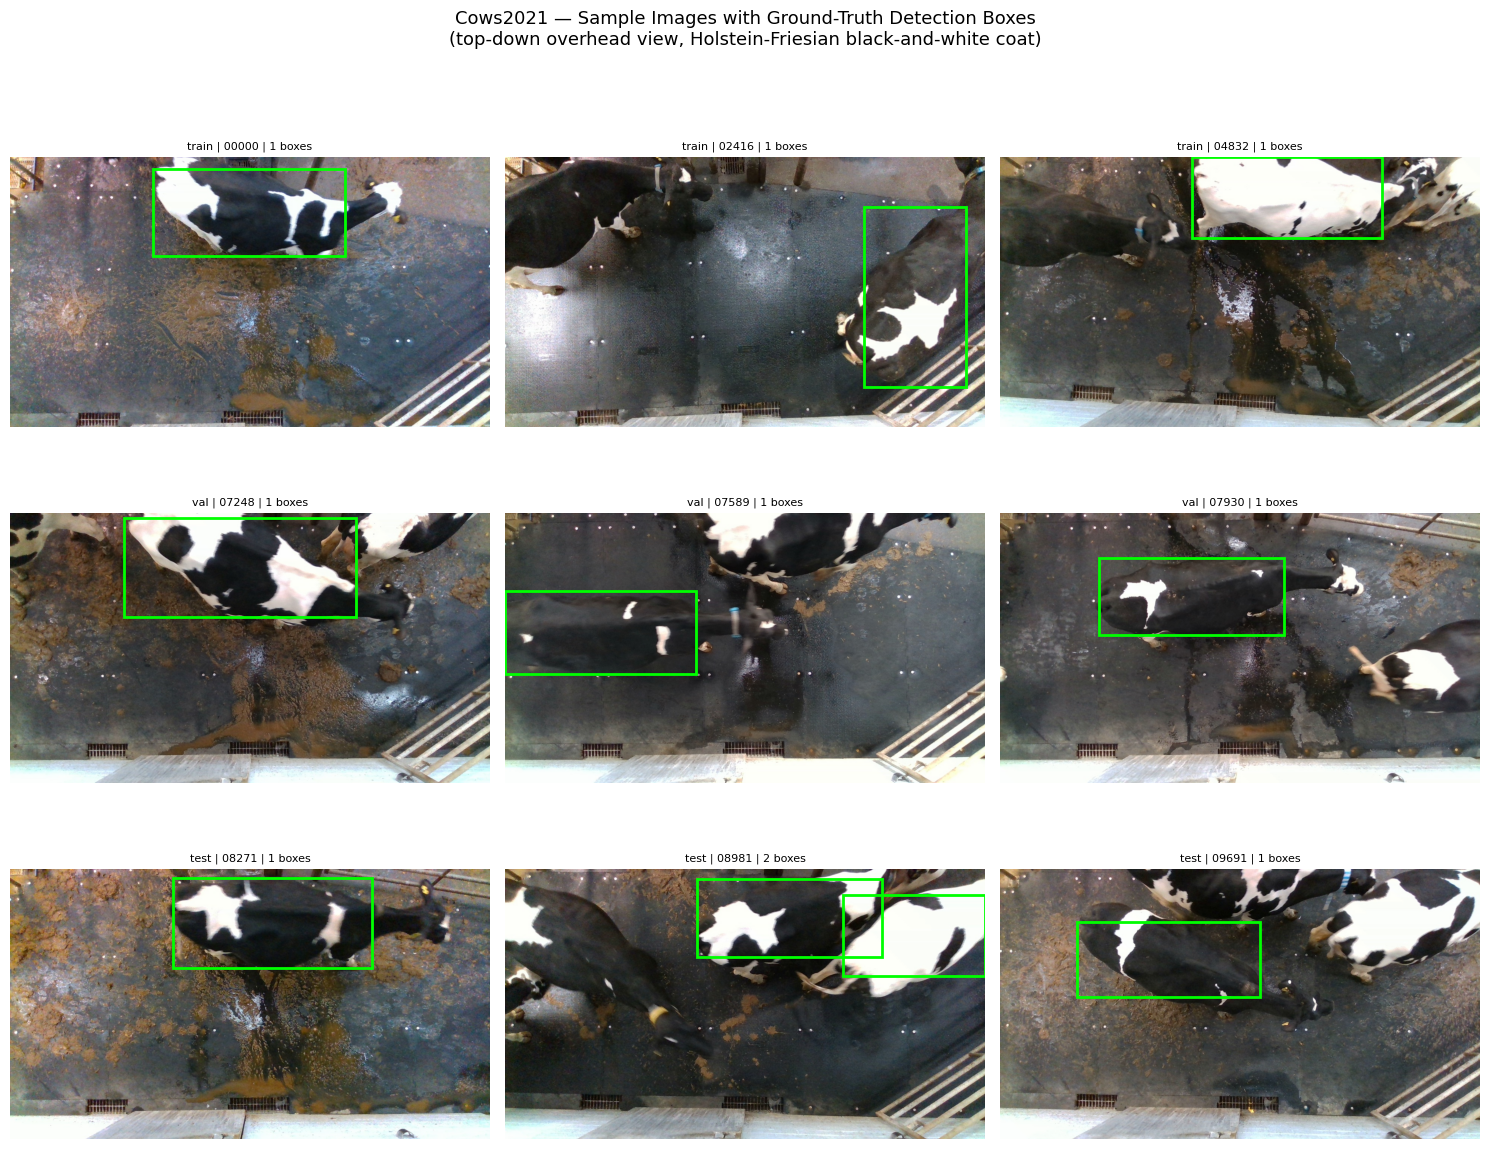

Saved: results/analysis/cows2021_sample_frames.png


In [3]:
# Pick 3 images per split, evenly spaced, and draw bounding boxes
sample_entries = []
for split in SPLITS:
    ann_files = sorted(ann_dir(split).glob("*.json"))
    step = max(1, len(ann_files) // 3)
    for af in ann_files[::step][:3]:
        img_path = img_dir(split) / af.name.replace(".json", "")
        sample_entries.append((split, img_path, af))

n_samples = len(sample_entries)
n_cols = 3
n_rows = (n_samples + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
fig.suptitle(
    "Cows2021 — Sample Images with Ground-Truth Detection Boxes\n"
    "(top-down overhead view, Holstein-Friesian black-and-white coat)",
    fontsize=13,
    y=1.01,
)

for ax, (split, img_path, ann_file) in zip(axes.flat, sample_entries):
    if not img_path.exists():
        ax.set_title(f"[missing] {img_path.name}", fontsize=8)
        ax.axis("off")
        continue

    img = Image.open(img_path)
    W, H = img.size
    d = json.loads(ann_file.read_text())
    boxes = [o for o in d["objects"] if o.get("classTitle") == "cattle torso"]

    ax.imshow(img)
    for obj in boxes:
        (x1, y1), (x2, y2) = obj["points"]["exterior"]
        rect = plt.Rectangle(
            (x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=2
        )
        ax.add_patch(rect)

    ax.set_title(f"{split} | {img_path.stem} | {len(boxes)} boxes", fontsize=8)
    ax.axis("off")

for ax in axes.flat[n_samples:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "cows2021_sample_frames.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/analysis/cows2021_sample_frames.png")

---

## 4. Annotation Format


In [4]:
# Parse one sample annotation file and display its structure
sample_ann_path = sorted(ann_dir("train").glob("*.json"))[0]
d = json.loads(sample_ann_path.read_text())

print(f"=== Supervisely JSON: {sample_ann_path.name} ===")
print()
print(f"Top-level keys:    {list(d.keys())}")
print(f"Image size:        {d['size']['width']}×{d['size']['height']} px (W×H)")
print(f"Objects count:     {len(d['objects'])}")
print()
if d["objects"]:
    obj0 = d["objects"][0]
    print("Sample object entry (objects[0]):")
    for k, v in obj0.items():
        print(f"  {k:<18} = {v}")
print()
print("Key fields:")
print("  classTitle         — always 'cattle torso' (single detection class)")
print("  points.exterior    — [[x1, y1], [x2, y2]] absolute pixel coordinates")
print("  geometryType       — 'rectangle'")
print()
print("Filename convention: {frame_id}.jpg.json")
print("  frame_id is a zero-padded 5-digit integer (00000–NNNNN)")
print("  Corresponding image: detection_and_localisation-{split}/img/{frame_id}.jpg")

=== Supervisely JSON: 00000.jpg.json ===

Top-level keys:    ['description', 'tags', 'size', 'objects']
Image size:        1280×720 px (W×H)
Objects count:     1

Sample object entry (objects[0]):
  id                 = 51088689
  classId            = 6462559
  description        = 
  geometryType       = rectangle
  labelerLogin       = inbox@datasetninja.com
  createdAt          = 2023-09-27T07:37:55.386Z
  updatedAt          = 2023-09-27T07:37:55.386Z
  tags               = []
  classTitle         = cattle torso
  points             = {'exterior': [[380, 31], [892, 263]], 'interior': []}

Key fields:
  classTitle         — always 'cattle torso' (single detection class)
  points.exterior    — [[x1, y1], [x2, y2]] absolute pixel coordinates
  geometryType       — 'rectangle'

Filename convention: {frame_id}.jpg.json
  frame_id is a zero-padded 5-digit integer (00000–NNNNN)
  Corresponding image: detection_and_localisation-{split}/img/{frame_id}.jpg


---

## 5. Class Distribution (Detection Box Counts)


In [5]:
print("Detection annotation class distribution — 'cattle torso' boxes per split")
print()
print(f"{'Split':<8} {'Images':>8} {'Boxes':>8} {'Avg boxes/img':>15}")
print("-" * 44)
for split in SPLITS:
    s = split_stats[split]
    avg = s["n_boxes"] / s["n_images"]
    print(f"{split:<8} {s['n_images']:>8,} {s['n_boxes']:>8,} {avg:>15.2f}")
print("-" * 44)
print(
    f"{'TOTAL':<8} {total_images:>8,} {total_boxes:>8,} "
    f"{total_boxes/total_images:>15.2f}"
)
print()
print("Note: All boxes belong to the single class 'cattle torso'.")
print("      No behavior labels are present in this dataset.")

Detection annotation class distribution — 'cattle torso' boxes per split

Split      Images    Boxes   Avg boxes/img
--------------------------------------------
train       7,248    9,408            1.30
val         1,023    1,238            1.21
test        2,131    2,532            1.19
--------------------------------------------
TOTAL      10,402   13,178            1.27

Note: All boxes belong to the single class 'cattle torso'.
      No behavior labels are present in this dataset.


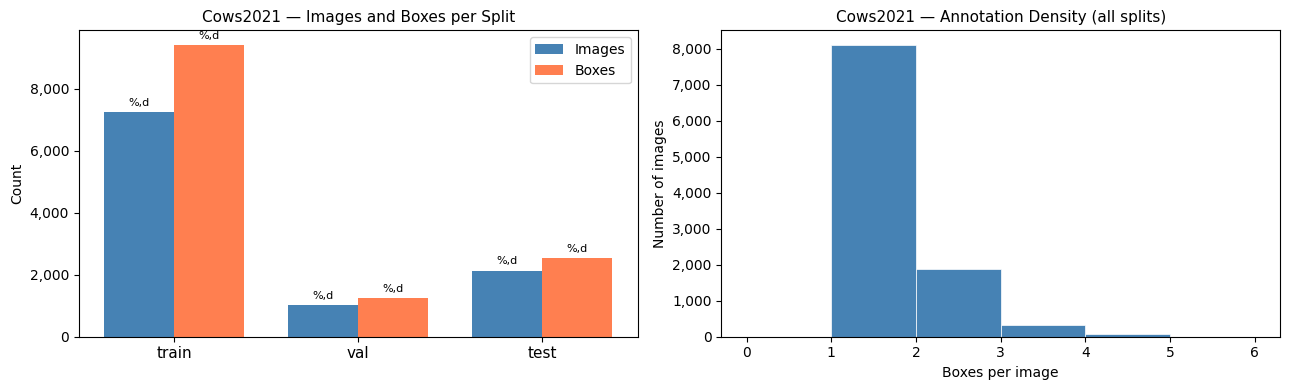

Saved: results/analysis/cows2021_class_distribution.png


In [6]:
# Histogram: boxes per image across all splits
all_bpi = [b for s in split_stats.values() for b in s["boxes_per_image"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: stacked bar chart of box counts per split
ax = axes[0]
box_counts = [split_stats[s]["n_boxes"] for s in SPLITS]
img_counts = [split_stats[s]["n_images"] for s in SPLITS]
x = np.arange(len(SPLITS))
width = 0.38
b1 = ax.bar(x - width / 2, img_counts, width, label="Images", color="steelblue")
b2 = ax.bar(x + width / 2, box_counts, width, label="Boxes", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(SPLITS, fontsize=11)
ax.set_ylabel("Count")
ax.set_title("Cows2021 — Images and Boxes per Split", fontsize=11)
ax.legend()
ax.bar_label(b1, fmt="%,d", fontsize=8, padding=3)
ax.bar_label(b2, fmt="%,d", fontsize=8, padding=3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))

# Right: histogram of boxes-per-image (annotation density)
ax2 = axes[1]
max_boxes = max(all_bpi)
ax2.hist(
    all_bpi,
    bins=range(0, max_boxes + 2),
    color="steelblue",
    edgecolor="white",
    linewidth=0.5,
)
ax2.set_xlabel("Boxes per image", fontsize=10)
ax2.set_ylabel("Number of images", fontsize=10)
ax2.set_title("Cows2021 — Annotation Density (all splits)", fontsize=11)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "cows2021_class_distribution.png", dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved: results/analysis/cows2021_class_distribution.png")

---

## 6. Resolution & Quality


In [7]:
# Collect resolutions from annotation JSONs (no need to open images)
resolutions: collections.Counter = collections.Counter()
sample_count = 0
for split in SPLITS:
    for f in sorted(ann_dir(split).glob("*.json"))[::50]:  # sample every 50th
        d = json.loads(f.read_text())
        resolutions[(d["size"]["width"], d["size"]["height"])] += 1
        sample_count += 1

dominant_res = resolutions.most_common(1)[0][0]
print(f"Sampled {sample_count} annotation files across all splits")
print(f"Resolutions found: {dict(resolutions)}")
print(f"Dominant resolution: {dominant_res[0]}×{dominant_res[1]} px (W×H)")

print()
print("Bounding box size statistics (all splits, pixels):")
box_widths = []
box_heights = []
box_areas = []
for split in SPLITS:
    for f in ann_dir(split).glob("*.json"):
        d = json.loads(f.read_text())
        W = d["size"]["width"]
        H = d["size"]["height"]
        for obj in d["objects"]:
            if obj.get("classTitle") == "cattle torso":
                (x1, y1), (x2, y2) = obj["points"]["exterior"]
                w = abs(x2 - x1)
                h = abs(y2 - y1)
                box_widths.append(w)
                box_heights.append(h)
                box_areas.append(w * h)

print(
    f"  Box width  — min={min(box_widths):.0f}  max={max(box_widths):.0f}  mean={np.mean(box_widths):.1f}  median={np.median(box_widths):.1f}"
)
print(
    f"  Box height — min={min(box_heights):.0f}  max={max(box_heights):.0f}  mean={np.mean(box_heights):.1f}  median={np.median(box_heights):.1f}"
)
print(
    f"  Box area   — min={min(box_areas):.0f}  max={max(box_areas):.0f}  mean={np.mean(box_areas):.0f}  median={np.median(box_areas):.0f}"
)
img_area = dominant_res[0] * dominant_res[1]
print(f"  Avg box as % of image area: {100 * np.mean(box_areas) / img_area:.1f}%")

Sampled 209 annotation files across all splits
Resolutions found: {(1280, 720): 209}
Dominant resolution: 1280×720 px (W×H)

Bounding box size statistics (all splits, pixels):
  Box width  — min=52  max=640  mean=488.4  median=510.0
  Box height — min=26  max=598  mean=243.7  median=226.0
  Box area   — min=2508  max=172800  mean=114160  median=113960
  Avg box as % of image area: 12.4%


In [8]:
# Image / annotation pairing check
missing = 0
total_checked = 0
for split in SPLITS:
    on_disk = {p.stem for p in img_dir(split).glob("*.jpg")}
    for f in ann_dir(split).glob("*.json"):
        total_checked += 1
        img_stem = f.name.replace(".json", "")  # e.g. '00000.jpg'
        stem = Path(img_stem).stem  # e.g. '00000'
        if stem not in on_disk:
            missing += 1

print(f"Annotation files checked: {total_checked:,}")
print(f"Missing images:           {missing:,}")
if missing == 0:
    print("\n✅ Every annotation file has a matching .jpg image.")
else:
    print(f"\n⚠️  {missing} annotation files have no matching image.")

Annotation files checked: 10,402
Missing images:           0

✅ Every annotation file has a matching .jpg image.


---

## 7. Evaluation Scope

> **This dataset has no behavior labels. It is used exclusively for detection and tracking evaluation in Phase 8.**

| Evaluation task          | In scope | Notes                                             |
| ------------------------ | -------- | ------------------------------------------------- |
| Detection mAP            | ✅ Yes   | OOD test for RF-DETR trained on CBVD-5 + CVB      |
| Short-term tracking IDF1 | ✅ Yes   | OC-SORT evaluated on overhead multi-cow sequences |
| Behavior classification  | ❌ No    | No behavior labels present                        |
| Activity budgets         | ❌ No    | No behavior labels present                        |
| Training                 | ❌ No    | Not used for model training                       |

**Why this dataset matters for Phase 8:**  
Cows2021 provides a strong OOD challenge because the camera viewpoint (overhead top-down) and breed appearance (black-and-white Holstein-Friesian pattern) are both entirely absent from the CBVD-5 and CVB training sets. A drop in detection mAP relative to in-distribution performance directly quantifies the viewpoint and appearance generalization gap.


In [9]:
print("Evaluation scope summary:")
print()
print("  Dataset role:         Phase 8 OOD detection + tracking evaluation")
print("  Behavior labels:      None")
print("  Detection class:      'cattle torso' → maps to 'cow' for RF-DETR evaluation")
print("  Split used for eval:  test  (2,131 images, 2,532 boxes)")
print("  Split used for tune:  val   (1,023 images, 1,238 boxes)  [optional]")
print("  Training split:       NOT used for any model training")
print()
print("  OOD challenge factors:")
print("    1. Camera viewpoint — overhead top-down vs. side-view in training data")
print(
    "    2. Breed appearance — Holstein-Friesian black-and-white coat not in training"
)
print("    3. Environment      — indoor barn vs. outdoor pasture/pen")

Evaluation scope summary:

  Dataset role:         Phase 8 OOD detection + tracking evaluation
  Behavior labels:      None
  Detection class:      'cattle torso' → maps to 'cow' for RF-DETR evaluation
  Split used for eval:  test  (2,131 images, 2,532 boxes)
  Split used for tune:  val   (1,023 images, 1,238 boxes)  [optional]
  Training split:       NOT used for any model training

  OOD challenge factors:
    1. Camera viewpoint — overhead top-down vs. side-view in training data
    2. Breed appearance — Holstein-Friesian black-and-white coat not in training
    3. Environment      — indoor barn vs. outdoor pasture/pen


---

## 8. Preprocessing Gap Analysis


In [10]:
print("Preprocessing steps required before Cows2021 enters the Phase 8 pipeline:")
print()
print("1. Convert annotation format")
print("   - Supervisely JSON → YOLO .txt or COCO JSON for RF-DETR evaluation.")
print("   - Map classTitle 'cattle torso' to class ID 0 ('cow').")
print("   - Convert points.exterior [[x1,y1],[x2,y2]] → absolute [x1,y1,x2,y2] boxes.")
print()
print("2. Detection inference (script 06_run_detection.sh)")
print("   - Run RF-DETR on Cows2021 test images to generate predictions.")
print("   - Compare predictions against ground-truth boxes for mAP computation.")
print()
print("3. Tracking evaluation (script 08_run_tracking.sh)")
print("   - Cows2021 is image-based, not video. For IDF1 evaluation, the temporal")
print("     ordering of images within a sequence must be inferred from frame indices.")
print("   - The consecutive naming (00000.jpg, 00001.jpg, ...) implies video order.")
print()
print("4. No tubelet generation needed")
print("   - Behavior classification is out of scope for this dataset.")
print()
print("5. No label remapping needed")
print("   - Single detection class. No behavior taxonomy alignment required.")

Preprocessing steps required before Cows2021 enters the Phase 8 pipeline:

1. Convert annotation format
   - Supervisely JSON → YOLO .txt or COCO JSON for RF-DETR evaluation.
   - Map classTitle 'cattle torso' to class ID 0 ('cow').
   - Convert points.exterior [[x1,y1],[x2,y2]] → absolute [x1,y1,x2,y2] boxes.

2. Detection inference (script 06_run_detection.sh)
   - Run RF-DETR on Cows2021 test images to generate predictions.
   - Compare predictions against ground-truth boxes for mAP computation.

3. Tracking evaluation (script 08_run_tracking.sh)
   - Cows2021 is image-based, not video. For IDF1 evaluation, the temporal
     ordering of images within a sequence must be inferred from frame indices.
   - The consecutive naming (00000.jpg, 00001.jpg, ...) implies video order.

4. No tubelet generation needed
   - Behavior classification is out of scope for this dataset.

5. No label remapping needed
   - Single detection class. No behavior taxonomy alignment required.


---

## 9. Summary JSON + Self-Consistency Check


In [11]:
summary = {
    "dataset": "cows2021",
    "total_images_or_frames": total_images,
    "total_annotations": total_boxes,
    "splits": {
        "train": split_stats["train"]["n_images"],
        "val": split_stats["val"]["n_images"],
        "test": split_stats["test"]["n_images"],
    },
    "class_distribution": {"cattle torso": total_boxes},
    "resolution": {"width": dominant_res[0], "height": dominant_res[1]},
    "has_behavior_labels": False,
    "evaluation_scope": ["detection_map", "tracking_idf1"],
}

# Schema validation
required_keys = [
    "dataset",
    "total_images_or_frames",
    "total_annotations",
    "splits",
    "class_distribution",
    "resolution",
    "has_behavior_labels",
    "evaluation_scope",
]
missing_keys = [k for k in required_keys if k not in summary]
assert not missing_keys, f"Missing schema keys: {missing_keys}"

non_int = {
    k: v
    for k, v in summary["class_distribution"].items()
    if not isinstance(v, int) or v <= 0
}
assert not non_int, f"class_distribution has invalid values: {non_int}"

out_path = RESULTS_DIR / "cows2021_summary.json"
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Summary JSON:")
print(json.dumps(summary, indent=2))
print(f"\n✅ Saved: {out_path}")

Summary JSON:
{
  "dataset": "cows2021",
  "total_images_or_frames": 10402,
  "total_annotations": 13178,
  "splits": {
    "train": 7248,
    "val": 1023,
    "test": 2131
  },
  "class_distribution": {
    "cattle torso": 13178
  },
  "resolution": {
    "width": 1280,
    "height": 720
  },
  "has_behavior_labels": false,
  "evaluation_scope": [
    "detection_map",
    "tracking_idf1"
  ]
}

✅ Saved: ../../results/analysis/cows2021_summary.json


In [12]:
# Self-consistency check against known Cows2021 dataset statistics
print("Self-consistency check:")
print("=" * 70)

checks = [
    (
        "Train images",
        split_stats["train"]["n_images"],
        7248,
        "== 7248 (paper / DatasetNinja)",
    ),
    (
        "Val images",
        split_stats["val"]["n_images"],
        1023,
        "== 1023 (paper / DatasetNinja)",
    ),
    (
        "Test images",
        split_stats["test"]["n_images"],
        2131,
        "== 2131 (paper / DatasetNinja)",
    ),
    ("Total images", total_images, 10402, "== 10402 (7248+1023+2131)"),
    ("Resolution W", dominant_res[0], 1280, "== 1280 px"),
    ("Resolution H", dominant_res[1], 720, "== 720 px"),
    (
        "Distinct classes",
        len(summary["class_distribution"]),
        1,
        "== 1 ('cattle torso' only)",
    ),
]

all_ok = True
for name, computed, expected, note in checks:
    ok = computed == expected
    status = "✅" if ok else "⚠️ "
    if not ok:
        all_ok = False
    print(f"{status} {name:<35} computed={computed:>7}  expected={expected:>7}  {note}")

print()
if all_ok:
    print("✅ All checks passed.")
else:
    print("⚠️  Some checks failed — review the values above.")

Self-consistency check:
✅ Train images                        computed=   7248  expected=   7248  == 7248 (paper / DatasetNinja)
✅ Val images                          computed=   1023  expected=   1023  == 1023 (paper / DatasetNinja)
✅ Test images                         computed=   2131  expected=   2131  == 2131 (paper / DatasetNinja)
✅ Total images                        computed=  10402  expected=  10402  == 10402 (7248+1023+2131)
✅ Resolution W                        computed=   1280  expected=   1280  == 1280 px
✅ Resolution H                        computed=    720  expected=    720  == 720 px
✅ Distinct classes                    computed=      1  expected=      1  == 1 ('cattle torso' only)

✅ All checks passed.
